# Schema for files

{
    "$schema": "http://json-schema.org/draft-04/schema#",
    "type": "object",
    "properties": {
        "name": {
            "type": "string"
        },
        "group": {
            "type": "string"
        },
        "metadata": {
            "type": "null"
        },
        "timers": {
            "type": "object",
            "properties": {
                "finished": {
                    "type": "string"
                },
                "started": {
                    "type": "string"
                },
                "vm-running": {
                    "type": "string"
                }
            },
            "required": [
                "finished",
                "started",
                "vm-running"
            ]
        },
        "metrics": {
            "type": "array",
            "items": [
                {
                    "type": "object",
                    "properties": {
                        "name": {
                            "type": "string"
                        },
                        "cpu": {
                            "type": "object",
                            "properties": {
                                "cores": {
                                    "type": "array",
                                    "items": [
                                        {
                                            "type": "number"
                                        },
                                        {
                                            "type": "number"
                                        },
                                        {
                                            "type": "number"
                                        },
                                        {
                                            "type": "number"
                                        },
                                        {
                                            "type": "number"
                                        }
                                    ]
                                },
                                "average": {
                                    "type": "number"
                                }
                            },
                            "required": [
                                "cores",
                                "average"
                            ]
                        },
                        "ram": {
                            "type": "number"
                        },
                        "disk": {
                            "type": "integer"
                        },
                        "timestamp": {
                            "type": "string"
                        }
                    },
                    "required": [
                        "name",
                        "cpu",
                        "ram",
                        "disk",
                        "timestamp"
                    ]
                }
            ]
        }
    },
    "required": [
        "name",
        "group",
        "metadata",
        "timers",
        "metrics"
    ]
}

In [277]:
# Install the required packages
%pip install matplotlib
%pip install Pillow
%pip install scipy
%pip install numpy
%pip install pandas
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [346]:
import os
import json
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import lines
from scipy.interpolate import make_interp_spline
import pandas as pd
import seaborn as sns

import numpy as np
from itertools import groupby

RESULTS_DIR = 'results'
PLOTS_DIR = '../../report/plt'

## Settings

In [394]:
SMALL_SIZE = 12
MEDIUM_SIZE = 13
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

## Load data

In [395]:
# Load results directory and parse out each test
def list_results():
    results = []

    results_files = os.listdir(RESULTS_DIR)
    for file in results_files:
        vmm, group, test, timestamp = file.removesuffix(".json").split('_', 3)
        
        # Parse content as json
        with open(f"{RESULTS_DIR}/{file}", "r") as f:
            content = f.read()
            json_content = json.loads(content)

        results.append({
            'vmm': vmm,
            'group': group,
            'test': test,
            # Parse from 2024-04-03-16-39-37 to datetime
            'timestamp': datetime.strptime(timestamp, "%Y-%m-%d-%H-%M-%S"),
            'data': json_content
        })


    return results       

results = list_results()

print(f"Found {len(results)} results")

Found 542 results


## Merge data

In [396]:
def merge_files(results, node_types):
    def merge_timers(results):
        merged_timers = {}
        for result in results:
            started = result['data']['timers']['started']
            
            duration = (datetime.fromisoformat(result['data']['timers']['finished']) - datetime.fromisoformat(started)).total_seconds()
            if 'duration' not in merged_timers:
                merged_timers['duration'] = []
            merged_timers['duration'].append(duration)


            for name, ts_list in result['data']['timers'].items():
                if name not in merged_timers:
                    merged_timers[name] = []

                diff = datetime.fromisoformat(ts_list) - datetime.fromisoformat(started)
                merged_timers[name].append(diff.total_seconds())

        for name, ts_list in merged_timers.items():
            merged_timers[name] = sum(ts_list) / len(ts_list)

        return merged_timers
        
    def combine_metrics(results):
        # Now we need to find out how many samples we have for each node group
        # To simplify visulization (stackplot) we will only keep as many results for a node group as the minumum has
        # So if worker-1 and worker-2 have 10 results, but worker-3 has 5, we will only use 5 results for each worker

        # So we start by grouping the node groups individually, then clamp the results to the minimum
        # Then merge each node groups into a single list
        # Then sort each list by dt

        all_metrics_by_name_and_timer = {}
        for result in results:
            started = result['data']['timers']['started']

            for metric in result['data']['metrics']:
                metric['dt'] = (datetime.fromisoformat(metric['timestamp']) - datetime.fromisoformat(started)).total_seconds()
            
                if metric['name'] not in all_metrics_by_name_and_timer:
                    all_metrics_by_name_and_timer[metric['name']] = {}

                # Use started timer as a unique key for the results file
                if started not in all_metrics_by_name_and_timer[metric['name']]:
                    all_metrics_by_name_and_timer[metric['name']][started] = []

                all_metrics_by_name_and_timer[metric['name']][started].append(metric)

        # Find the minimum number of samples for each node group
        if len([len(node_metrics) for node_metrics in all_metrics_by_name_and_timer.values()]) == 0:
            return []        

        min_samples = min([len(node_metrics) for node_metrics in all_metrics_by_name_and_timer.values()])
        for name, node_metrics in all_metrics_by_name_and_timer.items():
            # Keep only the first min_samples of items in node group, order doesnt matter
            new_dict = {}
            for i in range(min_samples):
                key = list(node_metrics.keys())[i]
                new_dict[key] = node_metrics[key]
            all_metrics_by_name_and_timer[name] = new_dict

        # Merge all node groups into a single list
        node_groups = {}
        for name, node_metrics in all_metrics_by_name_and_timer.items():
            for _, metrics in node_metrics.items():
                if name not in node_groups:
                    node_groups[name] = []

                node_groups[name].extend(metrics)

        # Sort all metrics by dt
        for name, metrics in node_groups.items():
            node_groups[name] = sorted(metrics, key=lambda x: x['dt'])

        # Now we have a list of metrics for each node group
        # Only return the node groups that match the node types.
        # control return everything that has control in the name
        # worker-<n> returns if end with -worker-<n>
        # worker-base returns if end with -worker-1 and -worker-2
        # worker-ext returns if not worker-base
        # worker-all returns if end with -worker-*

        res = {}
        for node_type in node_types:
            if node_type == "all":
                added = node_groups.values()
            elif node_type == "control":
                # if control in name
                added = [node_metrics for name, node_metrics in node_groups.items() if "control" in name]
            elif node_type == "worker-base":
                # if end with -worker-1 or -worker-2
                added = [node_metrics for name, node_metrics in node_groups.items() if name.endswith("-worker-1") or name.endswith("-worker-2")]
            elif node_type == "worker-ext":
                # if not worker-base and not control
                added = [node_metrics for name, node_metrics in node_groups.items() if not (name.endswith("-worker-1") or name.endswith("-worker-2")) and "control" not in name]
            elif node_type == "worker-all":
                # if end with -worker-*
                added = [node_metrics for name, node_metrics in node_groups.items() if "-worker-" in name]
            else:
                # if end with -worker-<n>
                added = [node_metrics for name, node_metrics in node_groups.items() if name.endswith(f"-{node_type}")]

            for node_metrics in added:
                if node_metrics[0]['name'] not in res:
                    res[node_metrics[0]['name']] = []

                res[node_metrics[0]['name']].extend(node_metrics)

        # Convert to list of (name, node_metrics)
        node_groups = [(name, node_metrics) for name, node_metrics in res.items()]
        

        return node_groups

    return (merge_timers(results), combine_metrics(results))


label = "kubevirt"
group = "create-vm"
name = "create-many"
matches = [result for result in results if result['vmm'] == label and result['group'] == group and result['test'] == name]

timers, metrics = merge_files(matches, ["all"])

print(timers)
for item in metrics[2][1]:
    print(item['cpu']['average'], " ", item['dt'])


{'duration': 63.03154427999998, 'finished': 63.03154427999998, 'started': 0.0, 'vm-running': 46.71503617999999}
0.042600000000000006   -10.843047
0.1696   -10.811089
0.040400000000000005   -10.486035
0.05025999999999999   -10.245378
0.03518   -10.243031
0.04536   -10.034416
0.025259999999999998   -9.97062
0.04012   -9.964203
0.0449   -9.921795
0.08821999999999999   -9.893926
0.034820000000000004   -9.863244
0.04296   -9.830569
0.035460000000000005   -9.718196
0.04018   -9.700163
0.06532   -9.658811
0.04022   -9.638081
0.0474   -9.564657
0.047599999999999996   -9.551955
0.04592   -9.506562
0.022760000000000002   -9.503501
0.04529999999999999   -9.317611
0.048400000000000006   -9.229729
0.03266   -9.209497
0.03796   -9.168607
0.042980000000000004   -8.843047
0.025259999999999998   -8.486035
0.05279999999999999   -8.245378
0.02782   -8.243031
0.0482   -7.97062
0.04742   -7.964203
0.037939999999999995   -7.921795
0.04529999999999999   -7.893926
0.035100000000000006   -7.863244
0.06322   -7

## Color utils

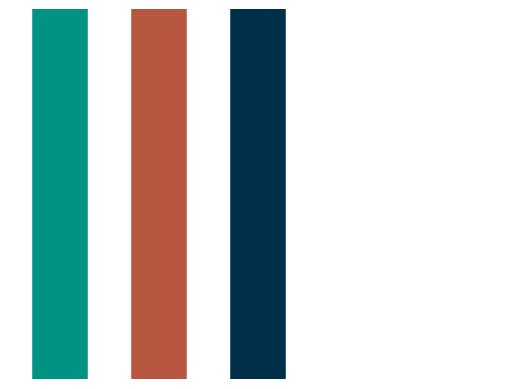

In [397]:
# three colors:
# 1. #009384
# 2. #b85741
# 3. #002f4a

colors = ["#009384", "#b85741", "#002f4a"]

def get_color(idx):
    return colors[idx % len(colors)]


def get_vmm_color(vmm):
    if vmm == "kubevirt":
        return get_color(0)
    elif vmm == "opennebula":
        return get_color(1)
    
    return get_color(2)

# Show colors in a plot next to each other
fig, ax = plt.subplots()
for idx, color in enumerate(colors):
    ax.add_line(lines.Line2D([idx * 0.2 + 0.1, idx * 0.2 + 0.1], [0, 1], color=color, linewidth=40))
plt.axis('off')
plt.show()

## Series helpers

In [398]:
def _get_formatted_x_y(x, y):
    method = 'rolling_mean'
    
    if method == 'rolling_mean':
        # Window size is 7 seconds of data
        #   Find how many data points in the first 5 seconds
        #   We assume x is time

        count = 0
        x_start = None
        for x_item in x:
            if x_start is None:
                x_start = x_item
            
            if x_item - x_start > 7:
                break

            count += 1
        
        print("Window size: ", count)
        window_size = count

        # if y is a list of lists, we need to apply rolling mean to each list
        if isinstance(y[0], list):
            y_new = []
            for yi in y:
                x = np.array(x[0:min(len(x), len(yi))])
                yi = np.array(yi[0:min(len(x), len(yi))])
                data = pd.DataFrame({'x': x, 'y': yi })
                data['y'] = data['y'].rolling(window=window_size, center=True).mean()
                y_new.append(data['y'])
        else:
            y_new = pd.Series(y).rolling(window=window_size).mean()

        return x, y_new
    
    return x, y

## Plot helpers

In [399]:
def clean_label(label):
    # replace kubevirt with KubeVirt and opennebula with OpenNebula, ram with RAM etc.
    replace = {
        "kubevirt": "KubeVirt",
        "opennebula": "OpenNebula",
        "ram": "RAM",
        "cpu": "CPU",
        "disk": "Disk",
        "duration": "Duration",
        "tiny": "Type-1",
        "small": "Type-2",
        "medium": "Type-3",
        "large": "Type-4",
        "create-": "Create ",
    }

    res = label
    for key, value in replace.items():
        res = res.replace(key, value)

    return res

def plot_line(ax, x, y, color):
    x['data'], y['data'] = _get_formatted_x_y(x['data'], y['data'])
    ax.plot(x['data'], y['data'], color=color, label=clean_label(y['label']),  linewidth=2.5)


def stack_plot(id, name, ax, x, y_list):
    x_res, y_list_res = _get_formatted_x_y(x['data'], [y['data'] for y in y_list])

    # Ensure x and all y's are the same length
    min_size = min([len(y) for y in y_list_res])
    min_size = min(min_size, len(x_res))

    x_res = x_res[:min_size]
    y_list_res = [y[:min_size] for y in y_list_res]

    colors=[get_color(id)]

    ax.stackplot(x_res, y_list_res, colors=colors, edgecolors=colors, alpha=0.7, labels=[clean_label(name)], linewidth=1.5)

def y_x_bar_plot(ax, x, y, color):
    ax.barh(x['data'], y['data'], color=color)

def plot_timers(ax, timers, min_y, max_y):
    for name, val in timers.items():
        # Skip started
        if name == 'started':
            continue            
        
        ax.plot([val, val],[min_y, max_y], label=clean_label(name), linestyle='--')
        

## Plot logic

In [408]:
def get_x_y(vmm, node_groups, timers, utilizations, label_prefix, bar_name=None):
    '''
    Returns multiple x axises (time in seconds since start, one for every node group) and multiple y axises (utilizations, same order as given)

    If duration is in utilizations, it will be data for a single bar in a bar plot
    '''

    x_axises = []
    y_axises = []

    if 'duration' in utilizations:
        # x is a list of node names
        # y is a list of durations

        name = bar_name if bar_name else vmm
        x_axises = [{"vmm": name, "data": name}]
        y_axises = [{"vmm": name, "data": timers['duration'], "label": label_prefix}]

        return x_axises, y_axises

    for name, node_metrics in node_groups:
        x_axis = []
        for metric in node_metrics:
            x_axis.append(metric['dt'])

        x_axises.append({"node": name, "data": x_axis})

    for utilization in utilizations:
        for name, node_metrics in node_groups:
            y_axis = []
            for metric in node_metrics:
                if utilization == 'cpu':
                    y_axis.append(metric[utilization]['average'] * 100)
                else:
                    y_axis.append(metric[utilization] * 100)


            # If more than one utilization, include utilization as suffix
            suffix = utilization if len(utilizations) > 1 else ""
        
            y_axises.append({"node": name, "data": y_axis, "label": label_prefix + " " + suffix})
        
    return x_axises, y_axises

def plot_results(name, vmms, group, test, node_types, utiliazations, stackplot: bool = False, filename: str = None):
    # Remove any utilization that is not 'cpu', 'ram' or 'disk'
    utiliazations = [utiliazation for utiliazation in utiliazations if utiliazation in ['cpu', 'ram', 'disk', 'duration']]
    if len(utiliazations) == 0:
        print(f"No valid utilizations found")
        return

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.set_title(name)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Utilization (%)')

    if len(vmms) > 1:
        print(f"Plotting {group}/{test} for {', '.join(vmms)}")
    else:   
        print(f"Plotting {group}/{test} for {vmms[0]}")

    # 1. Find result with group and test, choose latest if multiple
    for vmm_idx, vmm in enumerate(vmms):
        matches = [result for result in results if result['vmm'] == vmm and result['group'] == group and result['test'] == test]
        if len(matches) == 0:
            print(f"No results found for {vmm}/{group}/{test}")
            return
        
        print(f"Found {len(matches)} results for {vmm}/{group}/{test}")
        
        timers, node_groups = merge_files(matches, node_types)

        # If more than one VMM, include VMM as prefix
        prefix = vmm if len(vmms) > 1 else ""
        x_axises, y_axises = get_x_y(vmm, node_groups, timers, utiliazations, prefix)

        if len(x_axises) == 0:
            print(f"No x-data found for {vmm}/{group}/{test}")
            return
        
        if len(y_axises) == 0:
            print(f"No y-data found for {vmm}/{group}/{test}")
            return

        if 'duration' in utiliazations:
            for y_idx, y in enumerate(y_axises):
                x = x_axises[y_idx]
                y_x_bar_plot(ax, x, y, get_vmm_color(vmm))
        elif stackplot:
            stack_plot(vmm_idx, vmm, ax, x_axises[0], y_axises)
        else:
            for plot_idx, x_axis in enumerate(x_axises):
                
                # Find all its corresponding y axises
                y_axises = [y_axises[i] for i in range(plot_idx, len(y_axises), len(x_axises))]
                for y_idx, y_axis in enumerate(y_axises):
                    color = get_vmm_color(vmm) if len(vmms) > 1 else get_color(y_idx)
                    plot_line(ax, x_axis, y_axis, color)
                        
    ax.legend()
    plt.show()

    if filename:
        if not os.path.exists(PLOTS_DIR):
            os.makedirs(PLOTS_DIR)
        fig.savefig(os.path.join(PLOTS_DIR, filename), bbox_inches='tight')

def plot_duration(name, vmms, group_tests, filename: str = None):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.set_title(name)
    ax.set_xlabel('Duration (s)')

    if len(vmms) > 1:
        print(f"Bar plotting {name} for {', '.join(vmms)}")
    else:   
        print(f"Bar plotting {name} for {vmms[0]}")

    # 1. Find result with group and test, choose latest if multiple
    for vmm in vmms:
        for idx, item in enumerate(group_tests):
            group, test = item.split('/')
            matches = [result for result in results if result['vmm'] == vmm and result['group'] == group and result['test'] == test]
            if len(matches) == 0:
                print(f"No results found for {vmm}/{group}/{test}")
                y_x_bar_plot(ax, {"data": [clean_label(vmm)], "label": ""}, {"data": [0], "label": ""}, get_color(idx))
            else:
            
                print(f"Found {len(matches)} results for {vmm}/{group}/{test}")
                
                timers, node_groups = merge_files(matches, "all")

                # If more than one VMM, include VMM as prefix
                bar_name = vmm if len(vmms) > 1 else test
                x_axises, y_axises = get_x_y(vmm, node_groups, timers, ['duration'], "", bar_name=clean_label(bar_name))

                if len(x_axises) == 0:
                    print(f"No x-data found for {vmm}/{group}/{test}")
                    return
                
                if len(y_axises) == 0:
                    print(f"No y-data found for {vmm}/{group}/{test}")
                    return

                if len(vmm) == 1:
                    color = get_color(idx)
                else:
                    color = get_vmm_color(vmm)

                for y_idx, y in enumerate(y_axises):
                    x = x_axises[y_idx]
                    y_x_bar_plot(ax, x, y, color)

    plt.show()

    if filename:
        if not os.path.exists(PLOTS_DIR):
            os.makedirs(PLOTS_DIR)
        fig.savefig(os.path.join(PLOTS_DIR, filename), bbox_inches='tight')

## Plot data

Plotting create-vm/create-tiny for kubevirt
Found 48 results for kubevirt/create-vm/create-tiny
Window size:  65
Window size:  65
Window size:  65


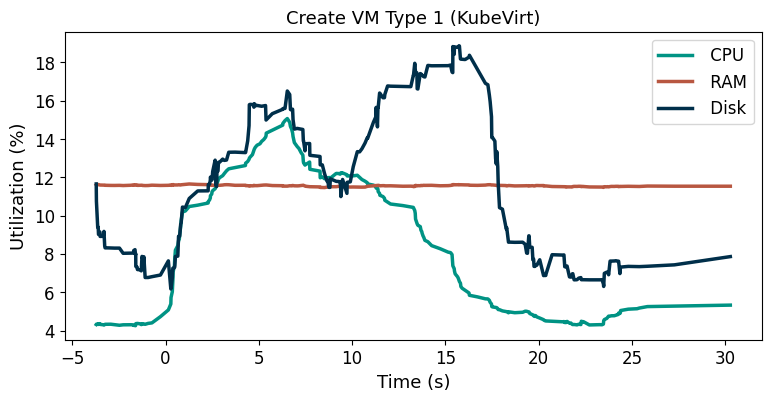

Plotting create-vm/create-tiny for opennebula
Found 48 results for opennebula/create-vm/create-tiny
Window size:  61
Window size:  61
Window size:  61


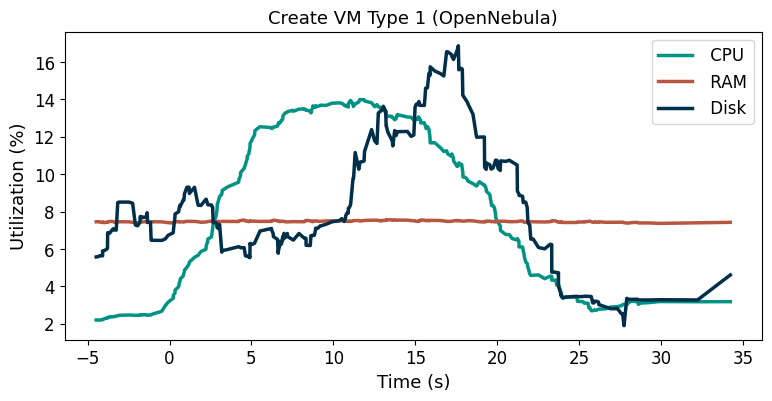

Plotting create-vm/create-tiny for kubevirt, opennebula
Found 48 results for kubevirt/create-vm/create-tiny
Window size:  72
Found 48 results for opennebula/create-vm/create-tiny
Window size:  67


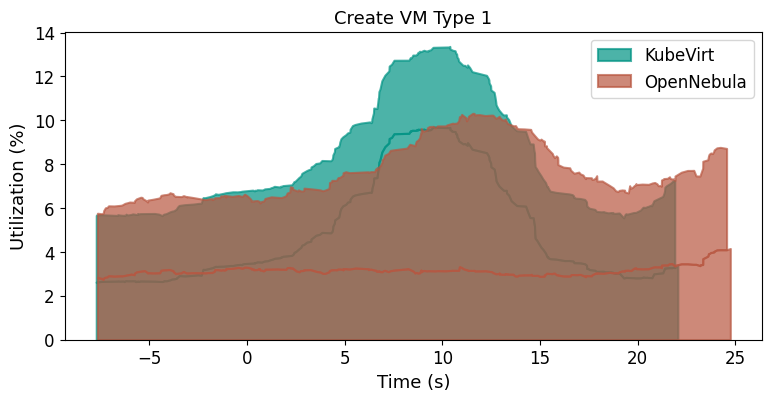

Plotting create-vm/create-small for kubevirt
Found 49 results for kubevirt/create-vm/create-small
Window size:  75
Window size:  75
Window size:  75


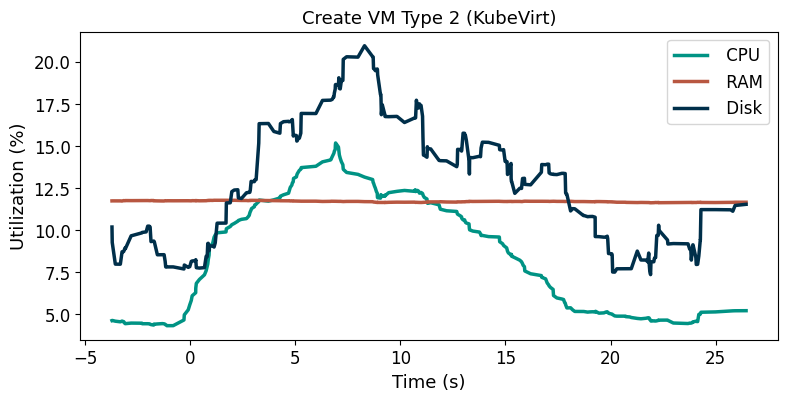

Plotting create-vm/create-small for opennebula
Found 48 results for opennebula/create-vm/create-small
Window size:  72
Window size:  72
Window size:  72


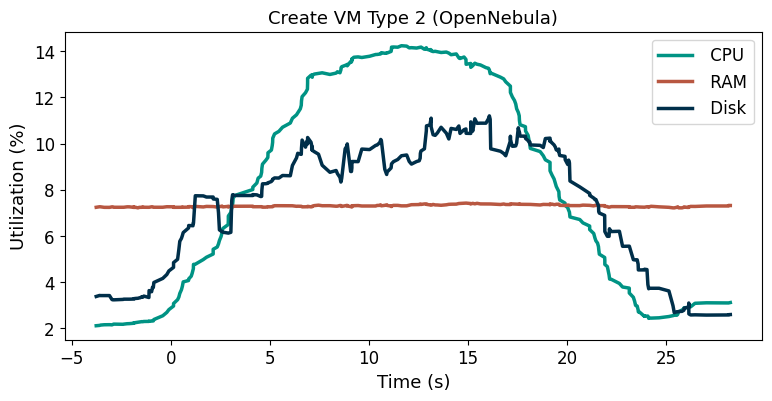

Plotting create-vm/create-small for kubevirt, opennebula
Found 49 results for kubevirt/create-vm/create-small
Window size:  74
Found 48 results for opennebula/create-vm/create-small
Window size:  72


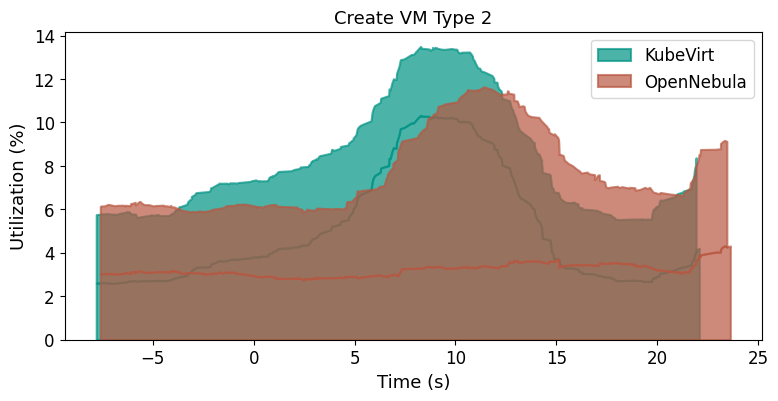

Plotting create-vm/create-medium for kubevirt
Found 49 results for kubevirt/create-vm/create-medium
Window size:  74
Window size:  74
Window size:  74


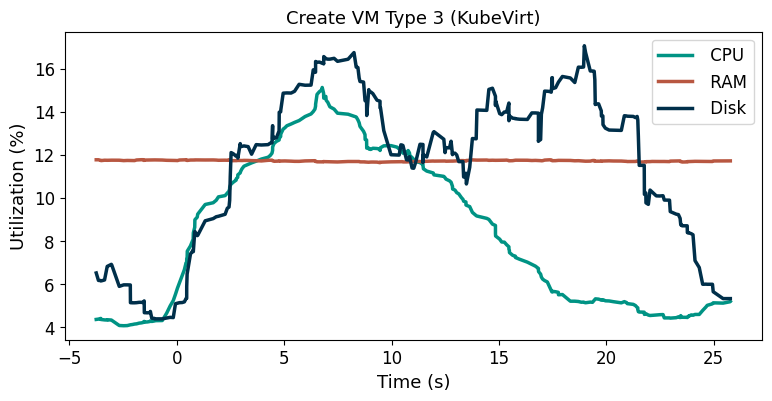

Plotting create-vm/create-medium for opennebula
Found 48 results for opennebula/create-vm/create-medium
Window size:  61
Window size:  61
Window size:  61


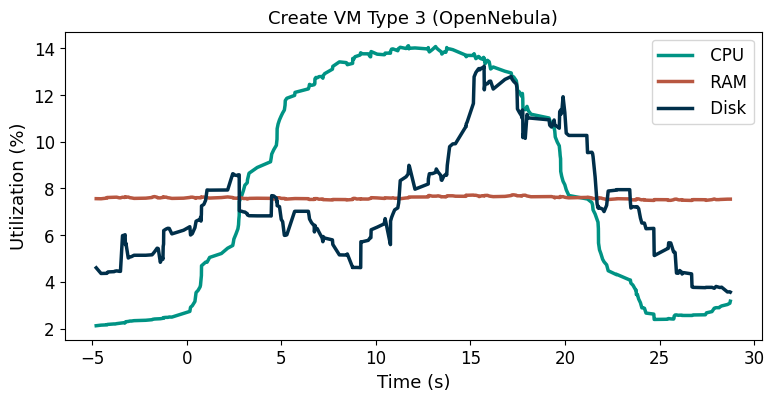

Plotting create-vm/create-medium for kubevirt, opennebula
Found 49 results for kubevirt/create-vm/create-medium
Window size:  74
Found 48 results for opennebula/create-vm/create-medium
Window size:  61


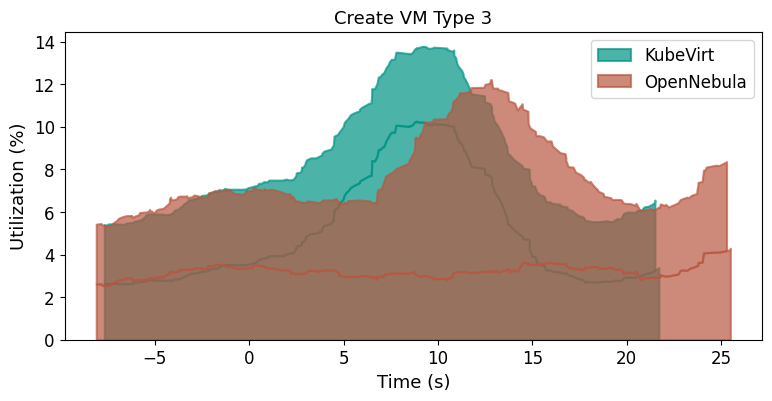

Plotting create-vm/create-large for kubevirt
Found 49 results for kubevirt/create-vm/create-large
Window size:  73
Window size:  73
Window size:  73


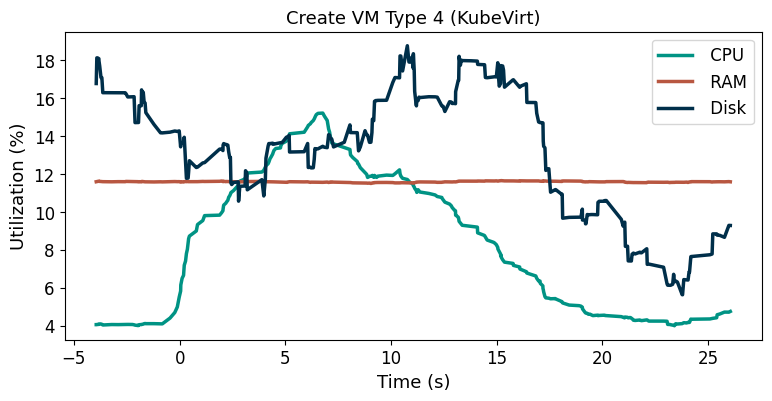

Plotting create-vm/create-large for opennebula
Found 48 results for opennebula/create-vm/create-large
Window size:  72
Window size:  72
Window size:  72


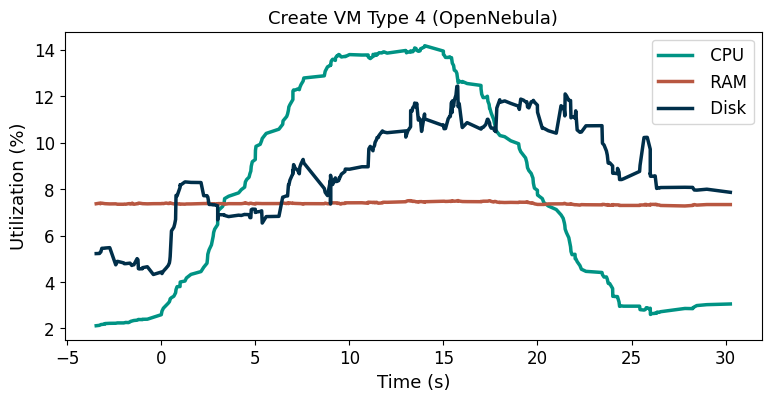

Plotting create-vm/create-large for kubevirt, opennebula
Found 49 results for kubevirt/create-vm/create-large
Window size:  71
Found 48 results for opennebula/create-vm/create-large
Window size:  74


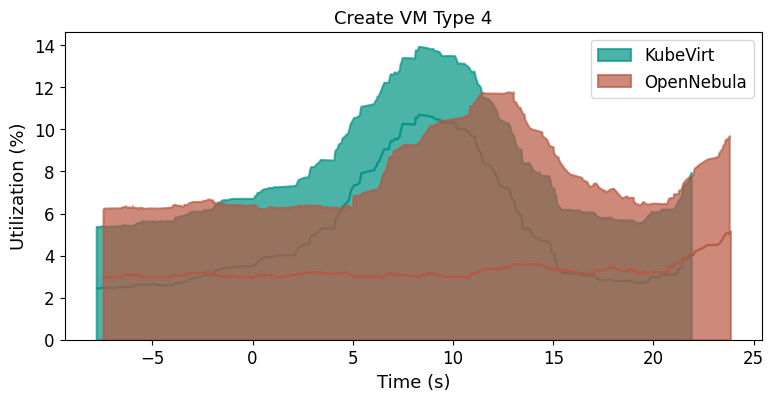

Plotting create-vm/create-many for kubevirt, opennebula
Found 50 results for kubevirt/create-vm/create-many
Window size:  79
Found 45 results for opennebula/create-vm/create-many
Window size:  80


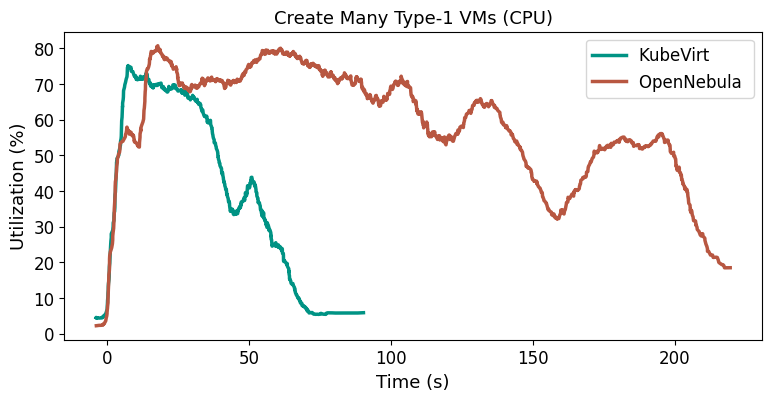

Plotting create-vm/create-many for kubevirt, opennebula
Found 50 results for kubevirt/create-vm/create-many
Window size:  78
Found 45 results for opennebula/create-vm/create-many
Window size:  78


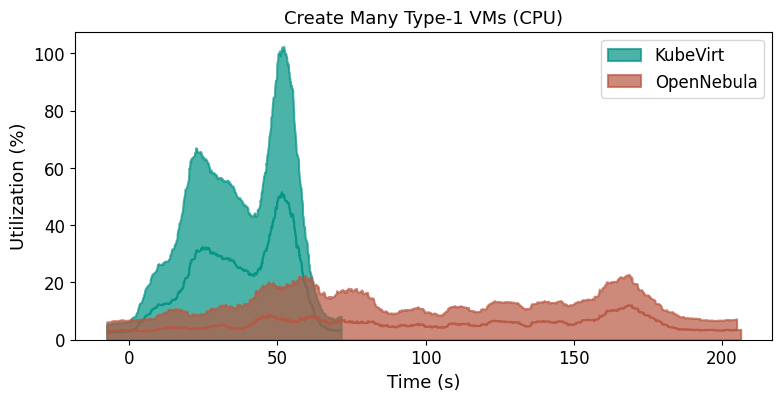

Plotting create-vm/create-many for kubevirt, opennebula
Found 50 results for kubevirt/create-vm/create-many
Window size:  79
Found 45 results for opennebula/create-vm/create-many
Window size:  80


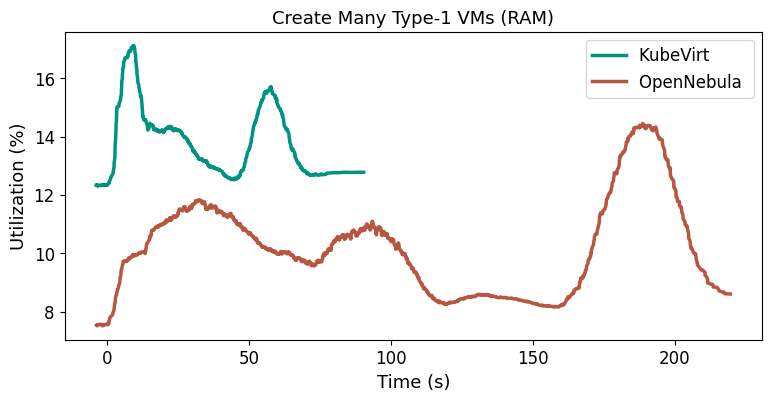

Plotting create-vm/create-many for kubevirt, opennebula
Found 50 results for kubevirt/create-vm/create-many
Window size:  78
Found 45 results for opennebula/create-vm/create-many
Window size:  78


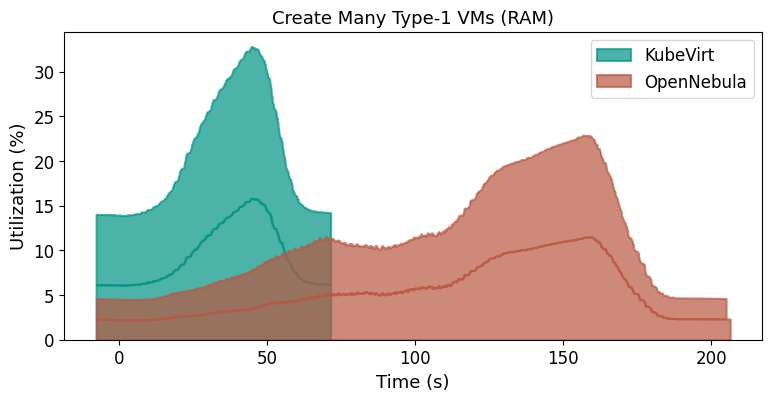

Plotting create-vm/create-many for kubevirt, opennebula
Found 50 results for kubevirt/create-vm/create-many
Window size:  79
Found 45 results for opennebula/create-vm/create-many
Window size:  80


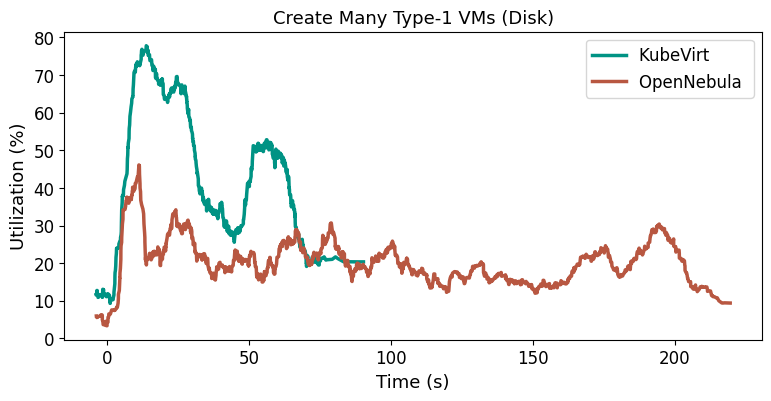

Plotting create-vm/create-many for kubevirt, opennebula
Found 50 results for kubevirt/create-vm/create-many
Window size:  78
Found 45 results for opennebula/create-vm/create-many
Window size:  78


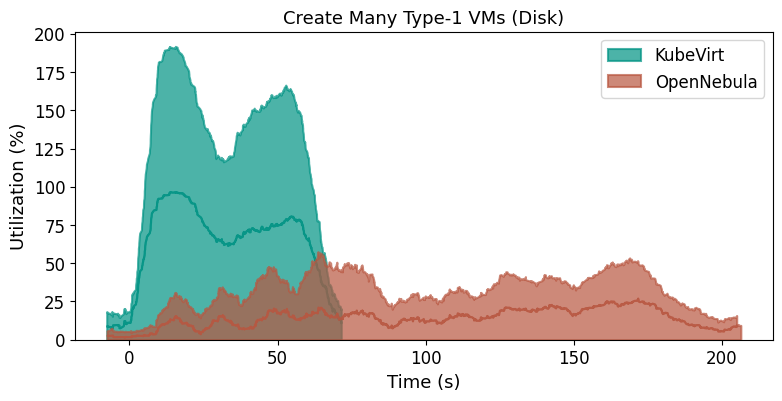

Plotting live-migrate/live-migrate for kubevirt, opennebula
Found 11 results for kubevirt/live-migrate/live-migrate
Window size:  41
Found 12 results for opennebula/live-migrate/live-migrate
Window size:  39


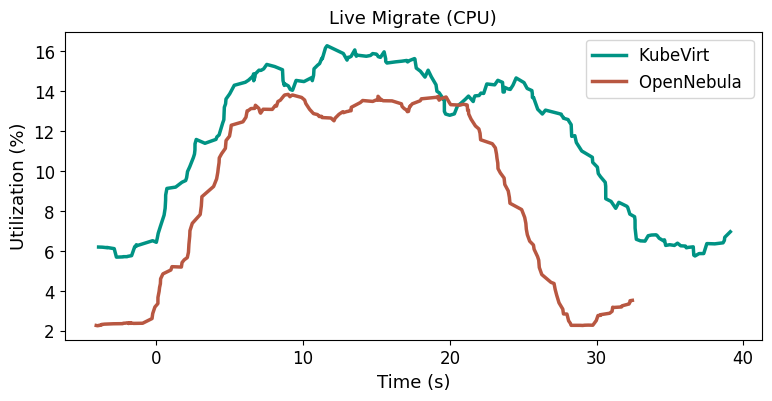

Plotting live-migrate/live-migrate for kubevirt, opennebula
Found 11 results for kubevirt/live-migrate/live-migrate
Window size:  39
Found 12 results for opennebula/live-migrate/live-migrate
Window size:  42


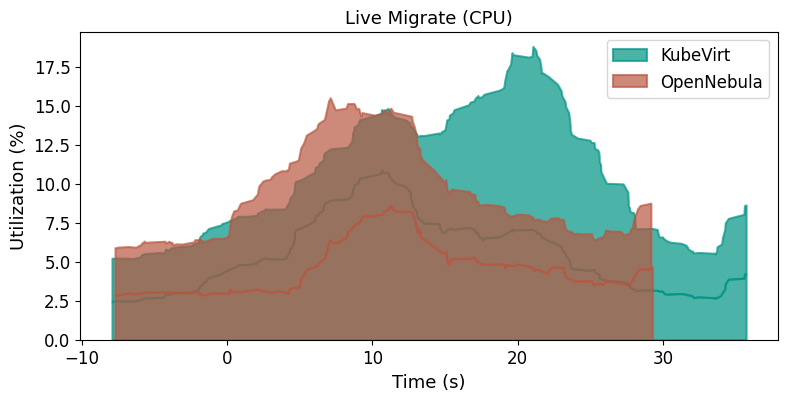

Plotting live-migrate/live-migrate for kubevirt, opennebula
Found 11 results for kubevirt/live-migrate/live-migrate
Window size:  41
Found 12 results for opennebula/live-migrate/live-migrate
Window size:  39


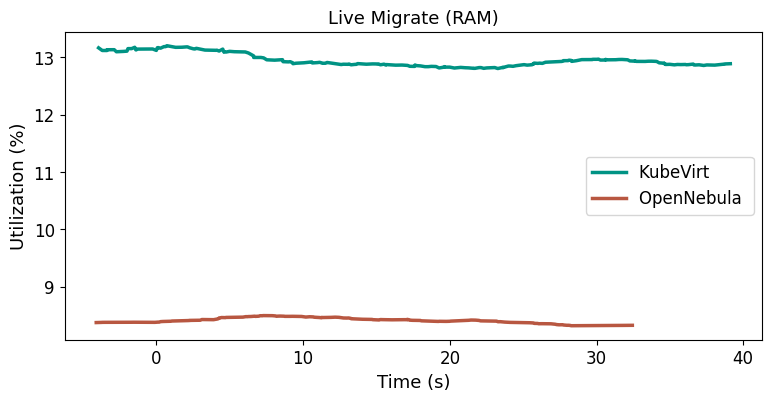

Plotting live-migrate/live-migrate for kubevirt, opennebula
Found 11 results for kubevirt/live-migrate/live-migrate
Window size:  39
Found 12 results for opennebula/live-migrate/live-migrate
Window size:  42


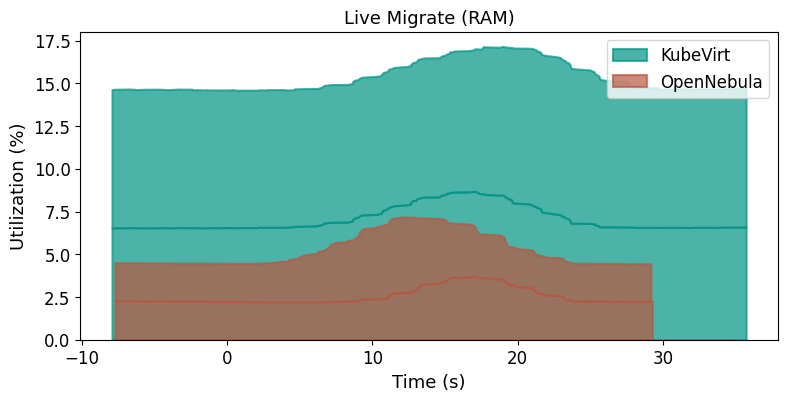

Plotting live-migrate/live-migrate for kubevirt, opennebula
Found 11 results for kubevirt/live-migrate/live-migrate
Window size:  41
Found 12 results for opennebula/live-migrate/live-migrate
Window size:  39


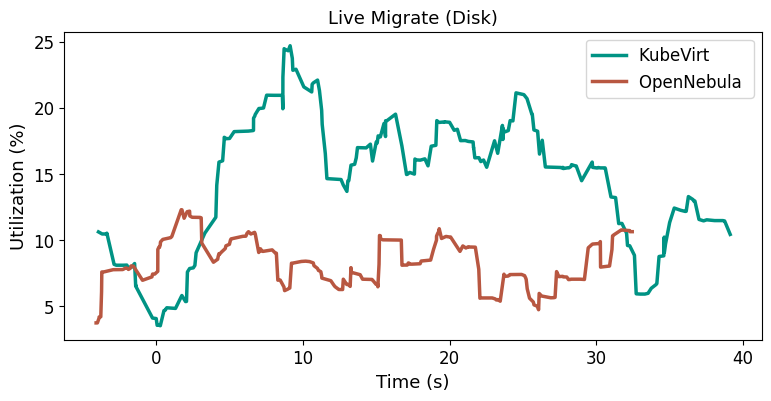

Plotting live-migrate/live-migrate for kubevirt, opennebula
Found 11 results for kubevirt/live-migrate/live-migrate
Window size:  39
Found 12 results for opennebula/live-migrate/live-migrate
Window size:  42


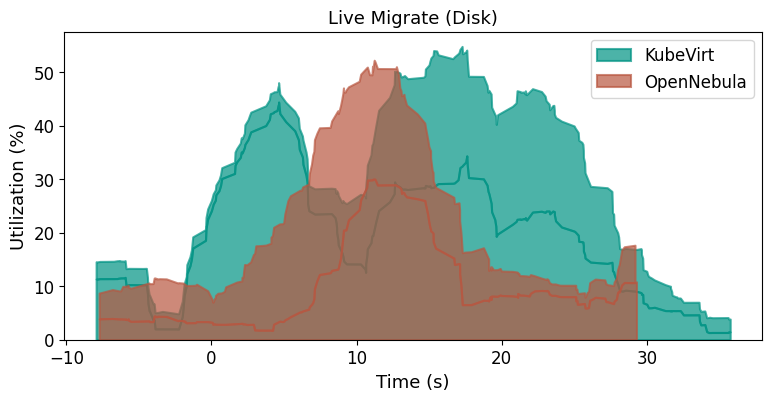

Plotting live-migrate/live-migrate-many for kubevirt, opennebula
Found 10 results for kubevirt/live-migrate/live-migrate-many
Window size:  35
Found 10 results for opennebula/live-migrate/live-migrate-many
Window size:  33


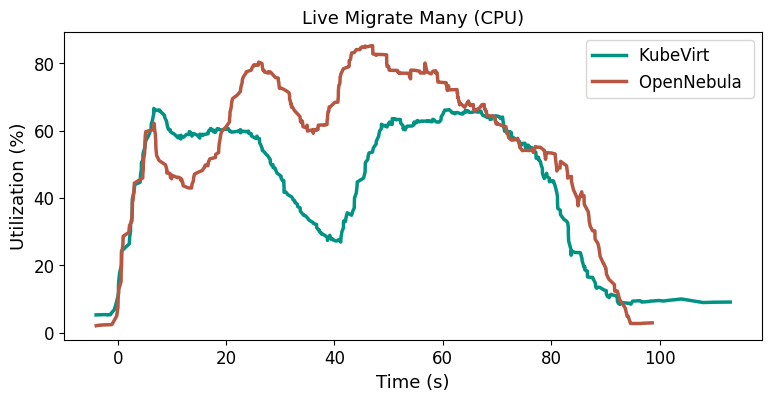

Plotting live-migrate/live-migrate-many for kubevirt, opennebula
Found 10 results for kubevirt/live-migrate/live-migrate-many
Window size:  38
Found 10 results for opennebula/live-migrate/live-migrate-many
Window size:  38


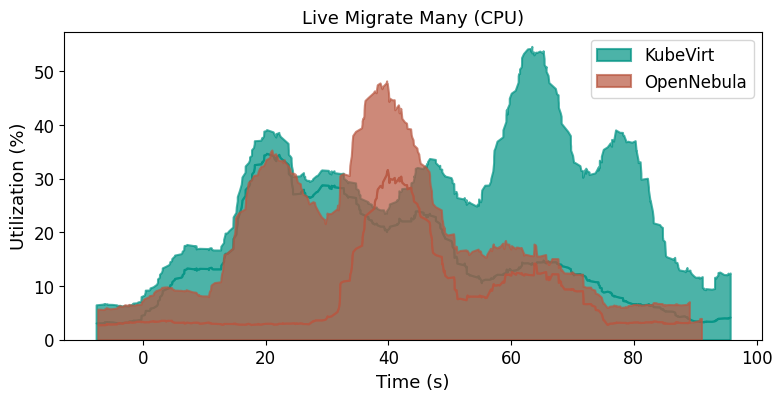

Plotting live-migrate/live-migrate-many for kubevirt, opennebula
Found 10 results for kubevirt/live-migrate/live-migrate-many
Window size:  35
Found 10 results for opennebula/live-migrate/live-migrate-many
Window size:  33


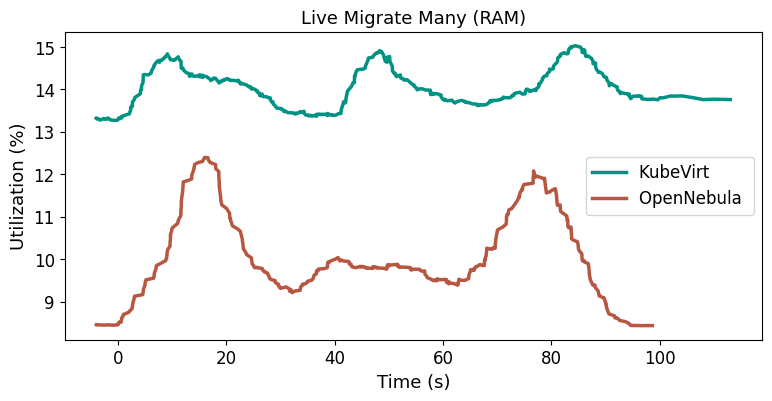

Plotting live-migrate/live-migrate-many for kubevirt, opennebula
Found 10 results for kubevirt/live-migrate/live-migrate-many
Window size:  38
Found 10 results for opennebula/live-migrate/live-migrate-many
Window size:  38


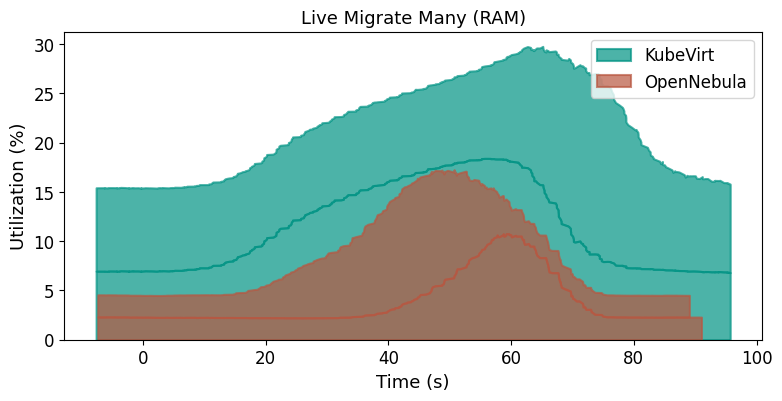

Plotting live-migrate/live-migrate-many for kubevirt, opennebula
Found 10 results for kubevirt/live-migrate/live-migrate-many
Window size:  35
Found 10 results for opennebula/live-migrate/live-migrate-many
Window size:  33


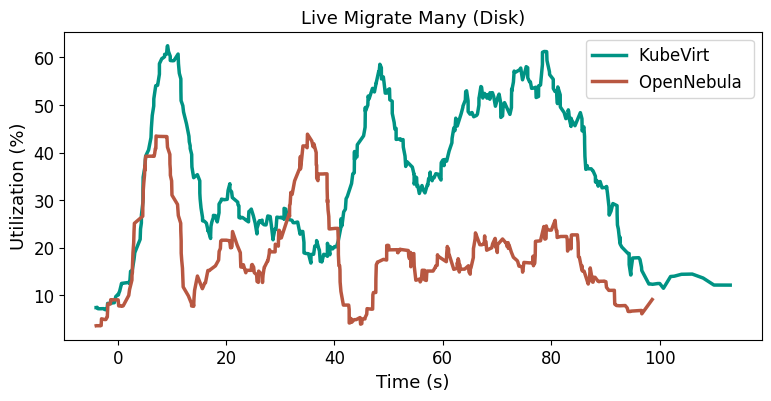

Plotting live-migrate/live-migrate-many for kubevirt, opennebula
Found 10 results for kubevirt/live-migrate/live-migrate-many
Window size:  38
Found 10 results for opennebula/live-migrate/live-migrate-many
Window size:  38


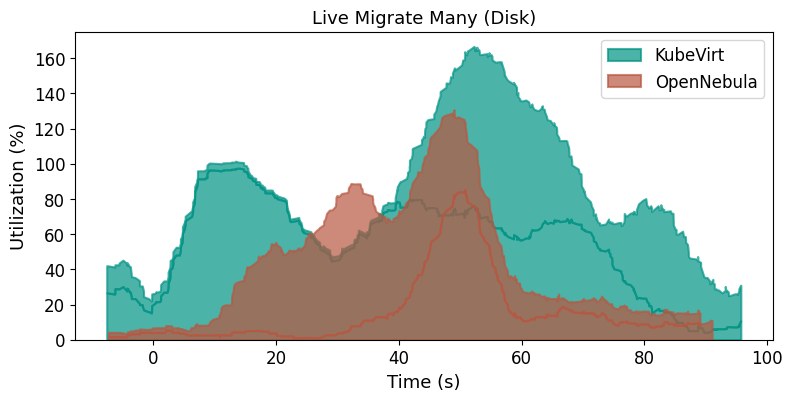

Plotting scale-cluster/scale-cluster for kubevirt, opennebula
Found 4 results for kubevirt/scale-cluster/scale-cluster
Window size:  13
Found 8 results for opennebula/scale-cluster/scale-cluster
Window size:  26


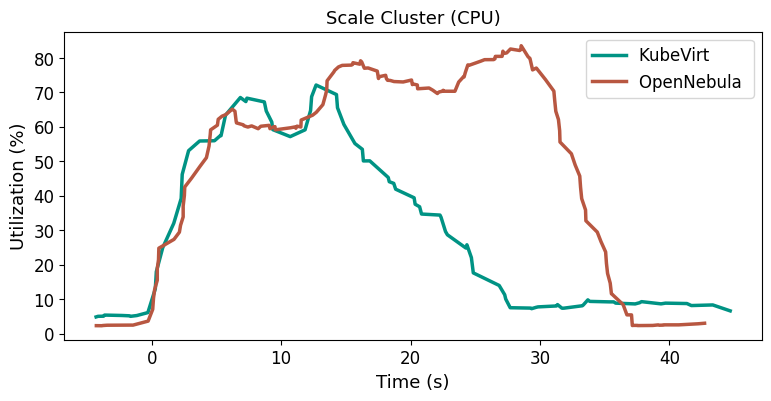

Plotting scale-cluster/scale-cluster for kubevirt, opennebula
Found 4 results for kubevirt/scale-cluster/scale-cluster
Window size:  14
Found 8 results for opennebula/scale-cluster/scale-cluster
Window size:  27


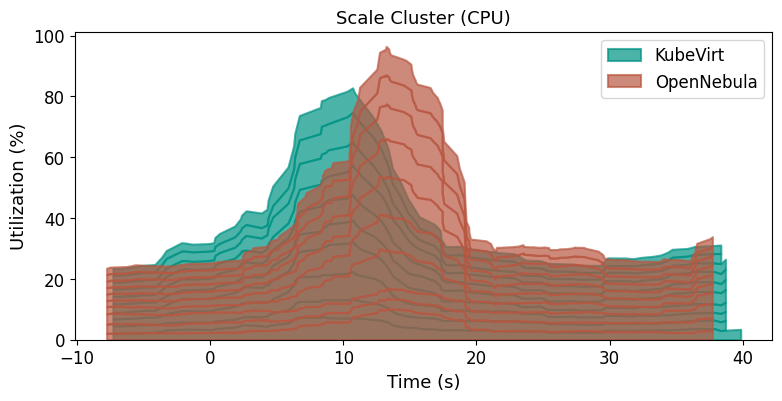

Plotting scale-cluster/scale-cluster for kubevirt, opennebula
Found 4 results for kubevirt/scale-cluster/scale-cluster
Window size:  13
Found 8 results for opennebula/scale-cluster/scale-cluster
Window size:  26


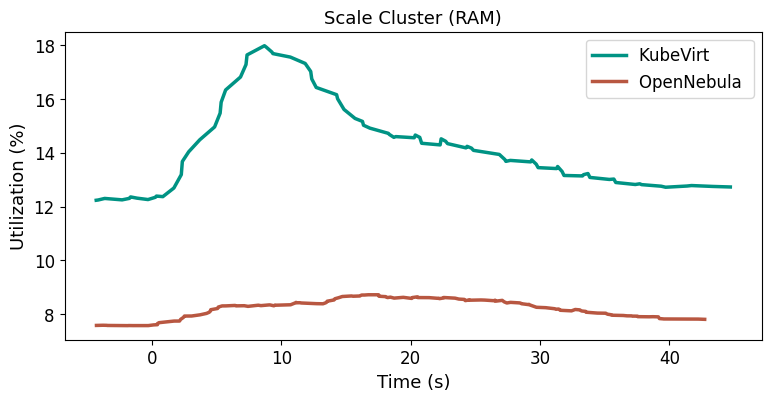

Plotting scale-cluster/scale-cluster for kubevirt, opennebula
Found 4 results for kubevirt/scale-cluster/scale-cluster
Window size:  14
Found 8 results for opennebula/scale-cluster/scale-cluster
Window size:  27


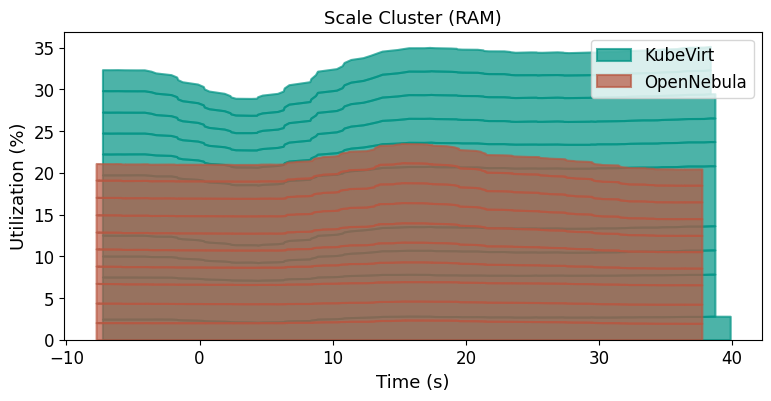

Plotting scale-cluster/scale-cluster for kubevirt, opennebula
Found 4 results for kubevirt/scale-cluster/scale-cluster
Window size:  13
Found 8 results for opennebula/scale-cluster/scale-cluster
Window size:  26


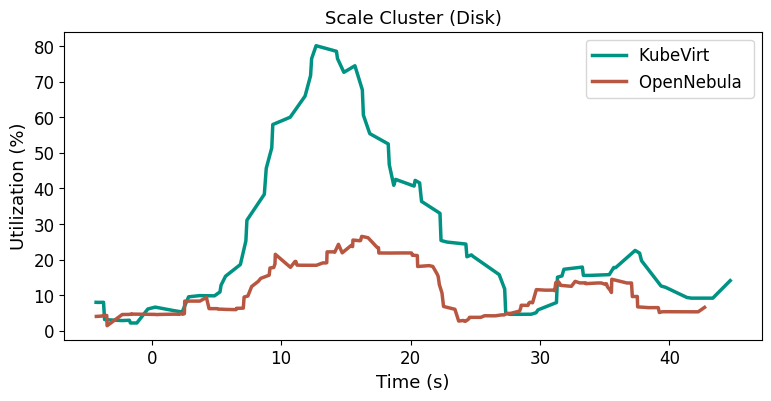

Plotting scale-cluster/scale-cluster for kubevirt, opennebula
Found 4 results for kubevirt/scale-cluster/scale-cluster
Window size:  14
Found 8 results for opennebula/scale-cluster/scale-cluster
Window size:  27


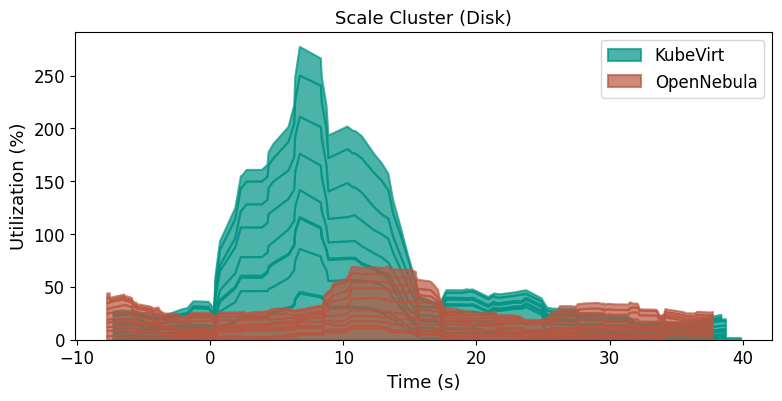

Plotting scale-cluster/scale-cluster-with-vms for kubevirt
Found 5 results for kubevirt/scale-cluster/scale-cluster-with-vms
Window size:  20


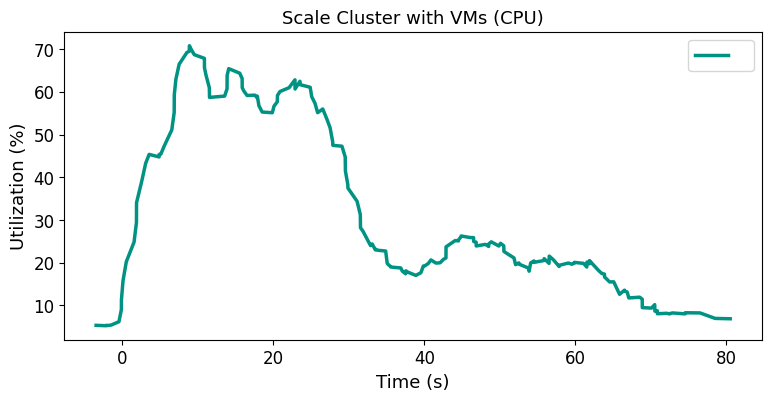

Plotting scale-cluster/scale-cluster-with-vms for kubevirt
Found 5 results for kubevirt/scale-cluster/scale-cluster-with-vms
Window size:  18


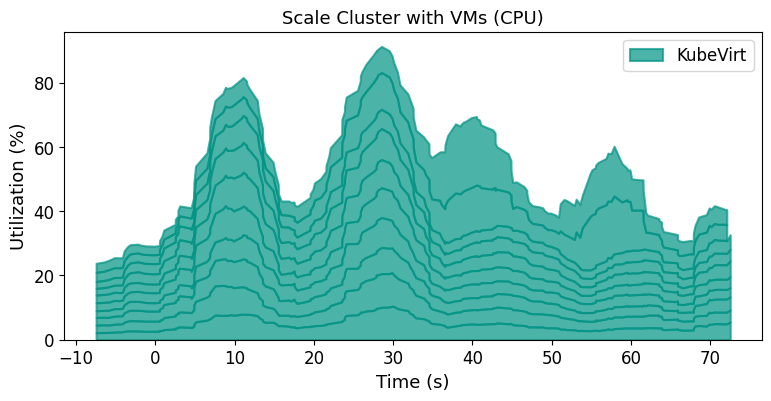

Plotting scale-cluster/scale-cluster-with-vms for kubevirt
Found 5 results for kubevirt/scale-cluster/scale-cluster-with-vms
Window size:  20


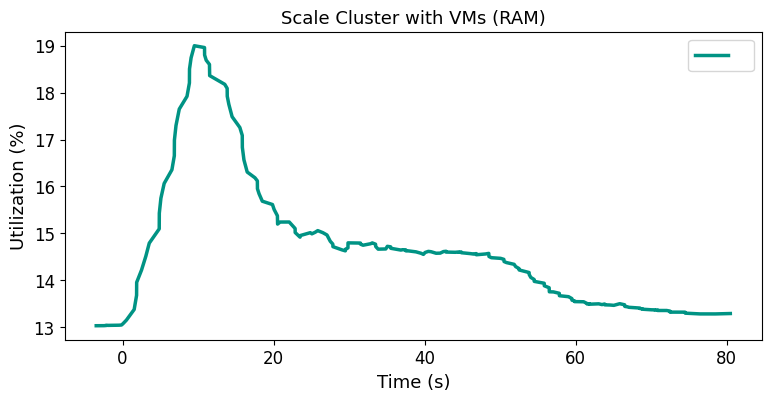

Plotting scale-cluster/scale-cluster-with-vms for kubevirt
Found 5 results for kubevirt/scale-cluster/scale-cluster-with-vms
Window size:  18


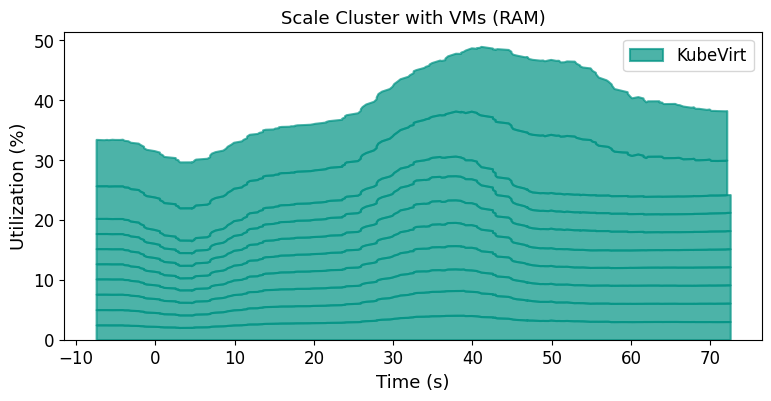

Plotting scale-cluster/scale-cluster-with-vms for kubevirt
Found 5 results for kubevirt/scale-cluster/scale-cluster-with-vms
Window size:  20


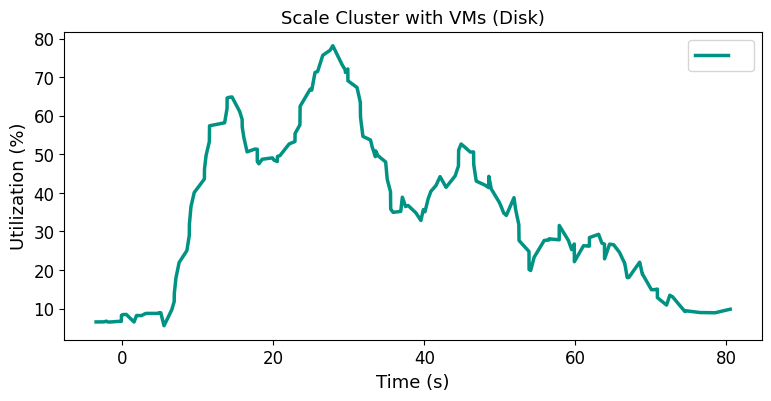

Plotting scale-cluster/scale-cluster-with-vms for kubevirt
Found 5 results for kubevirt/scale-cluster/scale-cluster-with-vms
Window size:  18


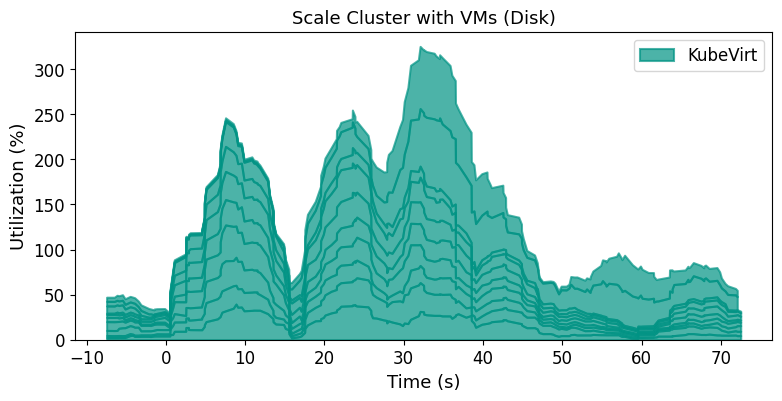

Bar plotting Create VMs (KubeVirt) for kubevirt
Found 48 results for kubevirt/create-vm/create-tiny
Found 49 results for kubevirt/create-vm/create-small
Found 49 results for kubevirt/create-vm/create-medium
Found 49 results for kubevirt/create-vm/create-large


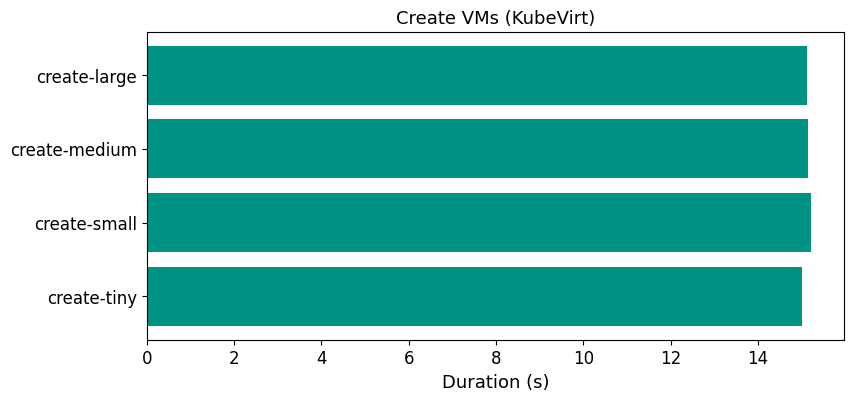

Bar plotting Create VMs (OpenNebula) for opennebula
Found 48 results for opennebula/create-vm/create-tiny
Found 48 results for opennebula/create-vm/create-small
Found 48 results for opennebula/create-vm/create-medium
Found 48 results for opennebula/create-vm/create-large


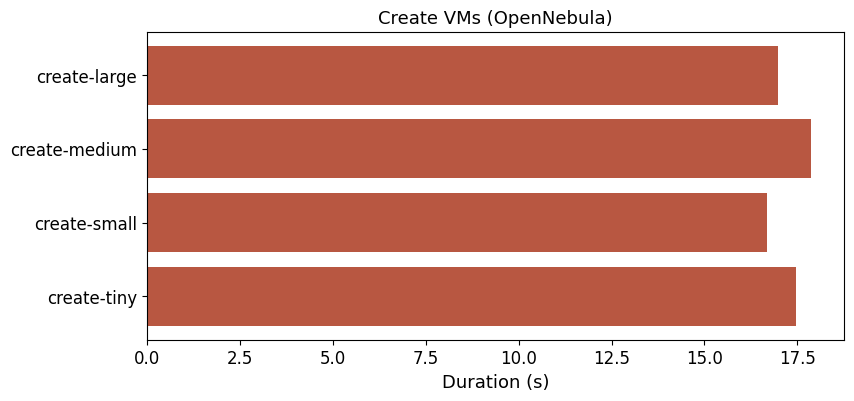

Bar plotting Create Many VMs (Duration) for kubevirt, opennebula
Found 50 results for kubevirt/create-vm/create-many
Found 45 results for opennebula/create-vm/create-many


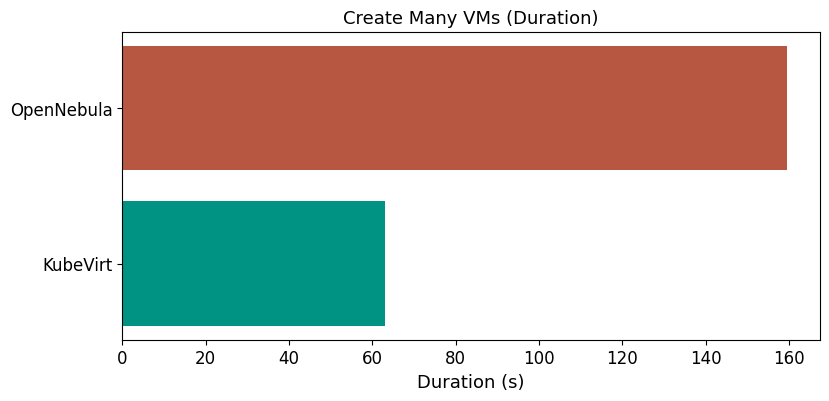

Bar plotting Live Migrate (Duration) for kubevirt, opennebula
Found 11 results for kubevirt/live-migrate/live-migrate
Found 12 results for opennebula/live-migrate/live-migrate


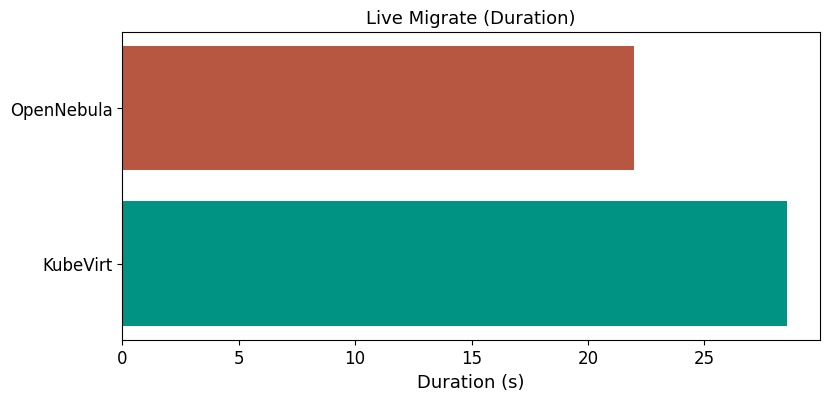

Bar plotting Live Migrate Many (Duration) for kubevirt, opennebula
Found 10 results for kubevirt/live-migrate/live-migrate-many
Found 10 results for opennebula/live-migrate/live-migrate-many


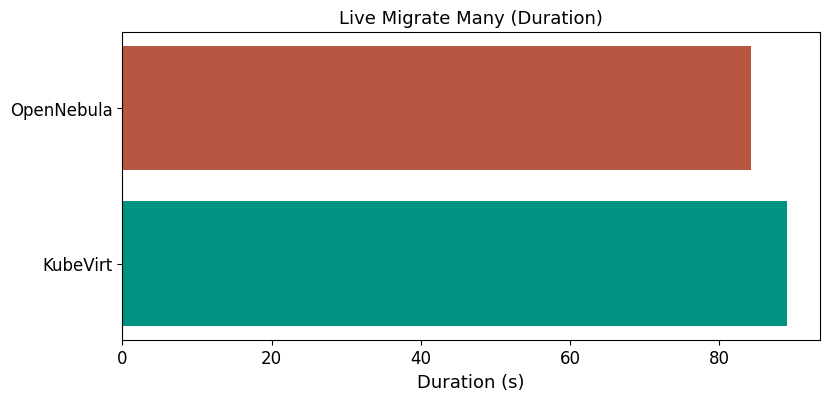

Bar plotting Scale Cluster (Duration) for kubevirt, opennebula
Found 4 results for kubevirt/scale-cluster/scale-cluster
Found 8 results for opennebula/scale-cluster/scale-cluster


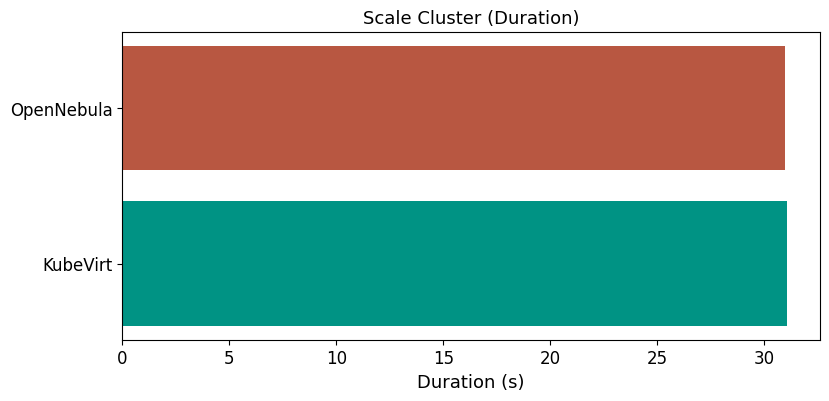

Bar plotting Scale Cluster with VMs (Duration) for kubevirt, opennebula
Found 5 results for kubevirt/scale-cluster/scale-cluster-with-vms
No results found for opennebula/scale-cluster/scale-cluster-with-vms


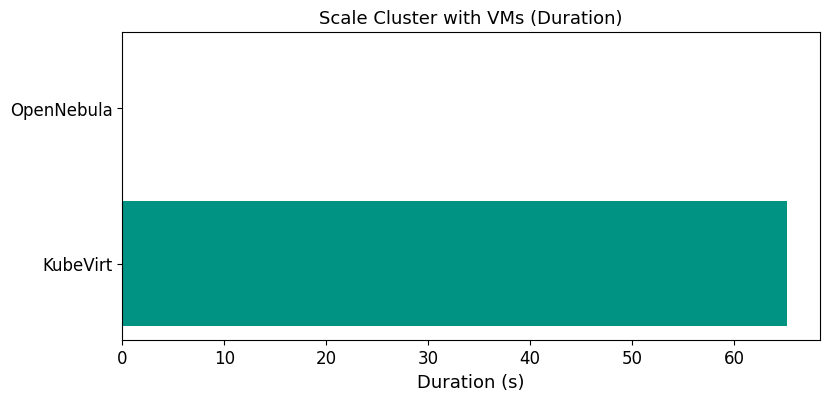

In [409]:
def util_name(util):
    if util == 'cpu':
        return 'CPU'
    if util == 'ram':
        return 'RAM'
    if util == 'disk':
        return 'Disk'
    if util == 'duration':
        return 'Duration'


for i, vm_type in enumerate(['tiny', 'small', 'medium', 'large']):
    plot_results(f'Create VM Type {i + 1} (KubeVirt)',['kubevirt'],'create-vm', 'create-'+vm_type, ['control'], ['cpu', 'ram', 'disk'], filename='create-'+vm_type+'_kubevirt.pdf')
    plot_results(f'Create VM Type {i + 1} (OpenNebula)',['opennebula'],'create-vm', 'create-'+vm_type, ['control'], ['cpu', 'ram', 'disk'], filename='create-'+vm_type+'_opennebula.pdf')
    plot_results(f'Create VM Type {i + 1}',['kubevirt', 'opennebula'],'create-vm', 'create-'+vm_type, ['worker-base'], ['cpu'], filename='create-'+vm_type+'_cpu_worker.pdf', stackplot=True)

# Create many
for util in ['cpu', 'ram', 'disk']:
    plot_results(f'Create Many Type-1 VMs ({util_name(util)})',['kubevirt', 'opennebula'],'create-vm', 'create-many', ['control'], [util], filename='create-many_'+util+'.pdf')
    plot_results(f'Create Many Type-1 VMs ({util_name(util)})',['kubevirt', 'opennebula'],'create-vm', 'create-many', ['worker-base'], [util], filename='create-many_'+util+'_worker.pdf', stackplot=True)

# Live migrate
for util in ['cpu', 'ram', 'disk']:
    plot_results(f'Live Migrate ({util_name(util)})',['kubevirt', 'opennebula'],'live-migrate', 'live-migrate', ['control'], [util], filename='live-migrate_'+util+'.pdf')
    plot_results(f'Live Migrate ({util_name(util)})',['kubevirt', 'opennebula'],'live-migrate', 'live-migrate', ['worker-base'], [util], filename='live-migrate_'+util+'_worker.pdf', stackplot=True)

# Live migrate many
for util in ['cpu', 'ram', 'disk']:
    plot_results(f'Live Migrate Many ({util_name(util)})',['kubevirt', 'opennebula'],'live-migrate', 'live-migrate-many', ['control'], [util], filename='live-migrate-many_'+util+'.pdf')
    plot_results(f'Live Migrate Many ({util_name(util)})',['kubevirt', 'opennebula'],'live-migrate', 'live-migrate-many', ['worker-base'], [util], filename='live-migrate-many_'+util+'_worker.pdf', stackplot=True)

# Scale cluster
for util in ['cpu', 'ram', 'disk']:
    plot_results(f'Scale Cluster ({util_name(util)})',['kubevirt', 'opennebula'],'scale-cluster', 'scale-cluster', ['control'], [util], filename='scale-cluster_'+util+'.pdf')
    plot_results(f'Scale Cluster ({util_name(util)})',['kubevirt', 'opennebula'],'scale-cluster', 'scale-cluster', ['worker-all'], [util], filename='scale-cluster_'+util+'_worker.pdf', stackplot=True)

# Scale cluster with VMs
#   - Only works for KubeVirt
for util in ['cpu', 'ram', 'disk']:
    plot_results(f'Scale Cluster with VMs ({util_name(util)})',['kubevirt'],'scale-cluster', 'scale-cluster-with-vms', ['control'], [util], filename='scale-cluster-with-vms_'+util+'.pdf')
    plot_results(f'Scale Cluster with VMs ({util_name(util)})',['kubevirt'],'scale-cluster', 'scale-cluster-with-vms', ['worker-all'], [util], filename='scale-cluster-with-vms_'+util+'_worker.pdf', stackplot=True)

# Durations
plot_duration(f'Create VMs (KubeVirt)', ['kubevirt'], ['create-vm/create-tiny', 'create-vm/create-small', 'create-vm/create-medium', 'create-vm/create-large'], filename='create-vms_duration_kubevirt.pdf')
plot_duration(f'Create VMs (OpenNebula)', ['opennebula'], ['create-vm/create-tiny', 'create-vm/create-small', 'create-vm/create-medium', 'create-vm/create-large'], filename='create-vms_duration_opennebula.pdf')
plot_duration(f'Create Many VMs (Duration)', ['kubevirt', 'opennebula'], ['create-vm/create-many'], filename='create-many_duration.pdf')
plot_duration(f'Live Migrate (Duration)', ['kubevirt', 'opennebula'], ['live-migrate/live-migrate'], filename='live-migrate_duration.pdf')
plot_duration(f'Live Migrate Many (Duration)', ['kubevirt', 'opennebula'], ['live-migrate/live-migrate-many'], filename='live-migrate-many_duration.pdf')
plot_duration(f'Scale Cluster (Duration)', ['kubevirt', 'opennebula'], ['scale-cluster/scale-cluster'], filename='scale-cluster_duration.pdf')
plot_duration(f'Scale Cluster with VMs (Duration)', ['kubevirt', 'opennebula'], ['scale-cluster/scale-cluster-with-vms'], filename='scale-cluster-with-vms_duration.pdf')
